### 1. Import Library & Konfigurasi Global

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import warnings

from mlxtend.frequent_patterns import apriori, association_rules
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load Dataset
df_arm = pd.read_csv('gshs2015_for_arm.csv')
cols_to_keep = [
    'gender_bin', 'jenjang_bin', 'flag_kesepian_bin', 'flag_khawatir_bin',
    'flag_dibully_bin', 'flag_diserang_bin', 'flag_alkohol_bin',
    'flag_narkoba_bin', 'flag_perokok_bin', 'target'
]
df_arm = df_arm[cols_to_keep]
display(HTML(f"<b>Data berhasil dimuat. Total Baris: {df_arm.shape[0]}, Total Kolom: {df_arm.shape[1]}</b>"))

### 2. Load Dataset

In [61]:
summary_rows = []
for col in df_arm.columns:
    n_one = int(df_arm[col].sum())
    pct   = n_one / len(df_arm) * 100
    summary_rows.append({'Kolom': col, 'Jumlah (=1)': f'{n_one:,}', 'Persentase': f'{pct:.1f}%'})

df_summary = pd.DataFrame(summary_rows)
styled = (df_summary.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
        dict(selector='caption', props=[('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]),
    ])
    .hide(axis='index')
    .set_caption('Distribusi Nilai Biner Per Kolom')
)
display(styled)

Kolom,Jumlah (=1),Persentase
gender_bin,"6,004",54.7%
jenjang_bin,"6,515",59.4%
flag_kesepian_bin,659,6.0%
flag_khawatir_bin,486,4.4%
flag_dibully_bin,"2,064",18.8%
flag_diserang_bin,"3,494",31.8%
flag_alkohol_bin,421,3.8%
flag_narkoba_bin,96,0.9%
flag_perokok_bin,315,2.9%
target,604,5.5%


### 3. Pemahaman Distribusi Data

In [62]:
from IPython.display import display, HTML

target_mask = df_arm['target'] == 1
n_target    = target_mask.sum()

rows = []
for col in df_arm.columns:
    if col == 'target':
        continue
    n = int((df_arm.loc[target_mask, col] == 1).sum())
    p = n / n_target * 100
    rows.append({'Kondisi': col, 'Jumlah': f'{n:,}', '% dari Target': p})

df_profil = pd.DataFrame(rows).sort_values('% dari Target', ascending=False)

styled_profil = (df_profil.style
    .format({'% dari Target': '{:.1f}%'})
    .bar(subset=['% dari Target'], color='#ff69b4', vmin=0, vmax=100)
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
    ])
    .hide(axis='index')
    .set_caption('Kondisi yang Dialami Pelajar dengan Niat Bunuh Diri')
)
display(styled_profil)

Kondisi,Jumlah,% dari Target
jenjang_bin,405,67.1%
gender_bin,389,64.4%
flag_diserang_bin,288,47.7%
flag_dibully_bin,231,38.2%
flag_kesepian_bin,125,20.7%
flag_khawatir_bin,101,16.7%
flag_alkohol_bin,66,10.9%
flag_perokok_bin,50,8.3%
flag_narkoba_bin,26,4.3%


### 4. Visualisasi Prevalensi Kondisi

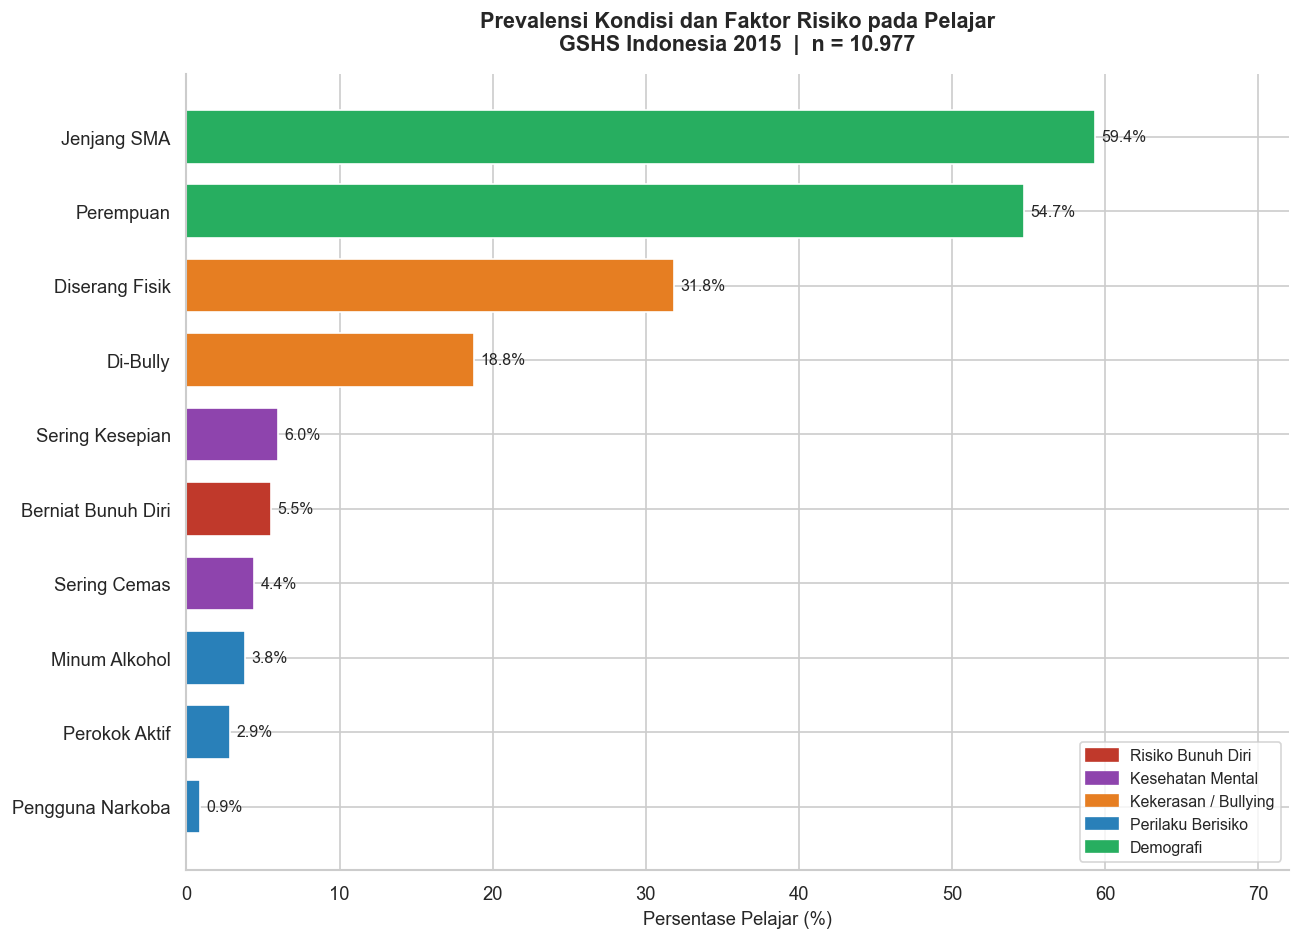

In [63]:
# rename
rename_display = {
    'flag_kesepian_bin'     : 'Sering Kesepian',
    'flag_khawatir_bin'     : 'Sering Cemas',
    'flag_dibully_bin'      : 'Di-Bully',
    'flag_diserang_bin'     : 'Diserang Fisik',
    'flag_perokok_bin'      : 'Perokok Aktif',
    'flag_alkohol_bin'      : 'Minum Alkohol',
    'flag_narkoba_bin'      : 'Pengguna Narkoba',
    'gender_bin'            : 'Perempuan',
    'jenjang_bin'           : 'Jenjang SMA',
    'target'                : 'Berniat Bunuh Diri',
}

df_display = df_arm.rename(columns=rename_display)
item_pct   = (df_display.sum() / len(df_display) * 100).sort_values(ascending=True)

# Warna per kategori
cat_map = {
    'Sering Kesepian':'mh',   'Sering Cemas':'mh',     'Sedikit Teman Dekat':'mh',
    'Berniat Bunuh Diri':'bd','Rencana Bunuh Diri':'bd','Percobaan Bunuh Diri':'bd',
    'Di-Bully':'kek',         'Diserang Fisik':'kek',
    'Perokok Aktif':'zat',    'Minum Alkohol':'zat',
    'Pengguna Narkoba':'zat', 'Aktif Fisik':'zat',
    'Perempuan':'demo',       'Jenjang SMA':'demo',
}
palette = {
    'bd' :'#c0392b',  # merah tua, bunuh diri
    'mh' :'#8e44ad',  # ungu, mental health
    'kek':'#e67e22',  # oranye, kekerasan
    'zat':'#2980b9',  # biru, zat/perilaku
    'demo':'#27ae60', # hijau, demografi
}
colors = [palette.get(cat_map.get(n, 'demo'), '#95a5a6') for n in item_pct.index]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(item_pct.index, item_pct.values,
               color=colors, edgecolor='white', height=0.72)

for bar, val in zip(bars, item_pct.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9.5)

patches_leg = [
    mpatches.Patch(color='#c0392b', label='Risiko Bunuh Diri'),
    mpatches.Patch(color='#8e44ad', label='Kesehatan Mental'),
    mpatches.Patch(color='#e67e22', label='Kekerasan / Bullying'),
    mpatches.Patch(color='#2980b9', label='Perilaku Berisiko'),
    mpatches.Patch(color='#27ae60', label='Demografi'),
]
ax.legend(handles=patches_leg, fontsize=9.5, loc='lower right')
ax.set_xlabel('Persentase Pelajar (%)', fontsize=11)
ax.set_xlim(0, 72)
ax.set_title(
    'Prevalensi Kondisi dan Faktor Risiko pada Pelajar\n'
    'GSHS Indonesia 2015  |  n = 10.977',
    fontsize=13, fontweight='bold', pad=14
)
plt.tight_layout()
plt.savefig('arm_fig1_prevalensi.png', bbox_inches='tight')
plt.show()

### 5. Heatmap Co-occurrence Antar Kondisi

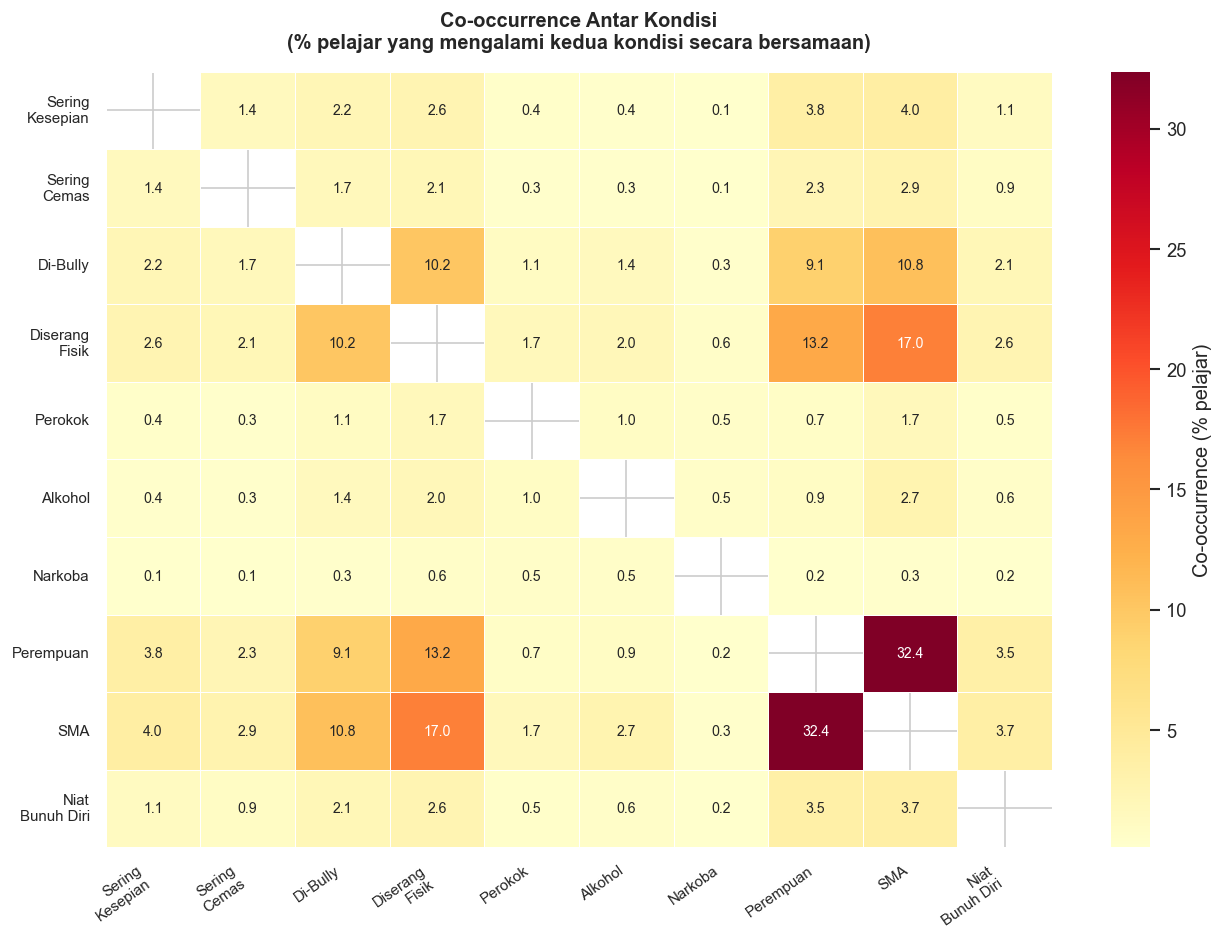

In [64]:
# 10 kondisi (9 prediktor + 1 target)
items_hm = [
    'flag_kesepian_bin', 'flag_khawatir_bin',
    'flag_dibully_bin',  'flag_diserang_bin',
    'flag_perokok_bin',  'flag_alkohol_bin', 'flag_narkoba_bin',
    'gender_bin', 'jenjang_bin', 'target'
]

labels_hm = [
    'Sering\nKesepian', 'Sering\nCemas',
    'Di-Bully', 'Diserang\nFisik',
    'Perokok', 'Alkohol', 'Narkoba',
    'Perempuan', 'SMA', 'Niat\nBunuh Diri'
]

# Hitung matriks co-occurrence dalam persen
basket_hm = df_arm[items_hm]
n = len(basket_hm)
cooc_data = [
    [round((basket_hm[a] & basket_hm[b]).sum() / n * 100, 2) for b in items_hm]
    for a in items_hm
]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cooc = pd.DataFrame(cooc_data, index=labels_hm, columns=labels_hm)

mask = np.eye(len(items_hm), dtype=bool)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cooc.astype(float),
    mask=mask,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8.5},
    cbar_kws={'label': 'Co-occurrence (% pelajar)'},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title(
    'Co-occurrence Antar Kondisi\n'
    '(% pelajar yang mengalami kedua kondisi secara bersamaan)',
    fontsize=12, fontweight='bold', pad=14
)
plt.tight_layout()
plt.savefig('arm_fig2_cooccurrence.png', bbox_inches='tight')
plt.show()

### 6. Persiapan Format Transaksi

In [65]:
rename_arm = {
    'flag_kesepian_bin'     : 'Sering_Kesepian',
    'flag_khawatir_bin'     : 'Sering_Cemas',
    'flag_dibully_bin'      : 'DiBully',
    'flag_diserang_bin'     : 'Diserang_Fisik',
    'flag_perokok_bin'      : 'Perokok',
    'flag_alkohol_bin'      : 'Minum_Alkohol',
    'flag_narkoba_bin'      : 'Pengguna_Narkoba',
    'gender_bin'            : 'Perempuan',
    'jenjang_bin'           : 'SMA',
    'target'                : 'Berniat_BunuhDiri',
}

basket = df_arm.rename(columns=rename_arm).astype(bool)

print(f"Shape   : {basket.shape[0]:,} baris × {basket.shape[1]} kolom")
print(f"Tipe    : {basket.dtypes.unique()[0]}")
print()
display(basket.head(3))

Shape   : 10,977 baris × 10 kolom
Tipe    : bool



,Perempuan,SMA,Sering_Kesepian,Sering_Cemas,DiBully,Diserang_Fisik,Minum_Alkohol,Pengguna_Narkoba,Perokok,Berniat_BunuhDiri
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,True,False,False,False,False


### 7. Pemilihan Threshold Support

In [66]:
from IPython.display import display, HTML

target_bd_cols = {'Berniat_BunuhDiri'}

rows = []
for sup in [0.005, 0.008, 0.010, 0.015, 0.020, 0.025]:
    fi  = apriori(basket, min_support=sup, use_colnames=True)
    r   = association_rules(fi, metric='lift', min_threshold=1.0)
    r_bd = r[r['consequents'].apply(lambda x: bool(x & target_bd_cols))]
    rows.append({
        'Min Support': f'{sup:.3f}',
        'Frequent Itemsets': len(fi),
        'Total Rules': len(r),
        'Rules → BD': len(r_bd)
    })

df_thresh = pd.DataFrame(rows)

def highlight_chosen(row):
    if row['Min Support'] == '0.010':
        return ['background-color: #eaecee; font-weight: bold; color: red'] * len(row)
    return [''] * len(row)

styled_thresh = (df_thresh.style
    .apply(highlight_chosen, axis=1)
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
    ])
    .hide(axis='index')
    .set_caption('Perbandingan Threshold Support')
)
display(styled_thresh)

Min Support,Frequent Itemsets,Total Rules,Rules → BD
0.005,103,462,81
0.008,74,260,37
0.010,57,150,22
0.015,41,74,9
0.020,34,52,7
0.025,28,32,6


### 8. Eksekusi Algoritma Apriori

In [67]:
from IPython.display import display, HTML

freq_items = apriori(basket, min_support=0.010, use_colnames=True)

freq_items['length']       = freq_items['itemsets'].apply(len)
freq_items['itemsets_str'] = freq_items['itemsets'].apply(lambda x: ', '.join(sorted(x)))
freq_items = freq_items.sort_values('support', ascending=False).reset_index(drop=True)

display(HTML(f"<h4>Total Frequent Itemsets: <span style='color:#e74c3c'>{len(freq_items)}</span></h4>"))

# Breakdown tabel
breakdown = freq_items['length'].value_counts().sort_index().reset_index()
breakdown.columns = ['Jumlah Item', 'Jumlah Itemset']
desc_map = {1:'Item Tunggal', 2:'Pasangan 2 Item', 3:'Kombinasi 3 Item', 4:'Kombinasi 4 Item'}
breakdown['Keterangan'] = breakdown['Jumlah Item'].map(desc_map).fillna('-')

styled_bd = (breakdown.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
    ])
    .hide(axis='index')
    .set_caption('Breakdown Frequent Itemsets')
)
display(styled_bd)

# Top 10 frequent itemsets
display(HTML("<b>Top 10 Frequent Itemsets:</b>"))
top_fi = freq_items[['itemsets_str', 'support', 'length']].head(10).copy()
top_fi.columns = ['Itemset', 'Support', 'Panjang']

styled_fi = (top_fi.style
    .format({'Support': '{:.4f}'})
    .background_gradient(cmap='Blues', subset=['Support'])
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
    ])
    .hide(axis='index')
)
display(styled_fi)

Jumlah Item,Jumlah Itemset,Keterangan
1,9,Item Tunggal
2,26,Pasangan 2 Item
3,21,Kombinasi 3 Item
4,1,Kombinasi 4 Item


Itemset,Support,Panjang
SMA,0.5935,1
Perempuan,0.5470,1
"Perempuan, SMA",0.3237,2
Diserang_Fisik,0.3183,1
DiBully,0.1880,1
"Diserang_Fisik, SMA",0.1704,2
"Diserang_Fisik, Perempuan",0.1316,2
"DiBully, SMA",0.1080,2
"DiBully, Diserang_Fisik",0.1018,2
"DiBully, Perempuan",0.0906,2


### 9. Association Rules

Dari frequent itemsets kita bentuk rules **A → B** dan hitung empat metrik:

| Metrik | Rumus | Arti |
|--------|-------|------|
| **Support** | P(A ∪ B) | Seberapa sering A dan B muncul bersama |
| **Confidence** | P(B\|A) | Jika A terjadi, seberapa sering B juga terjadi |
| **Lift** | Conf / P(B) | Seberapa jauh di atas "kebetulan". >1 = hubungan nyata |
| **Conviction** | (1−P(B)) / (1−Conf) | Seberapa "meyakinkan" implikasi A→B |

In [68]:
from IPython.display import display, HTML

rules = association_rules(freq_items, metric='lift', min_threshold=1.0)

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

display(HTML(f"<h4>Total Rules Dihasilkan: <span style='color:#e74c3c'>{len(rules)}</span></h4>"))

# Statistik
desc = rules[['support', 'confidence', 'lift', 'conviction']].describe().round(4).T
desc.columns = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']

styled_desc = (desc.style
    .background_gradient(cmap='YlOrRd', subset=['Mean', 'Max'])
    .format('{:.4f}', subset=['Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max'])
    .format('{:.0f}', subset=['Count'])
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
        dict(selector='caption', props=[('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]),
    ])
    .set_caption('Statistik Metrik Association Rules')
)
display(styled_desc)

,Count,Mean,Std,Min,25%,50%,75%,Max
support,150,0.0202,0.0135,0.0103,0.0128,0.0148,0.0239,0.1018
confidence,150,0.2642,0.2162,0.0173,0.0683,0.2138,0.4146,0.7095
lift,150,1.6928,0.6783,1.0002,1.1738,1.5677,1.9827,5.4153
conviction,150,1.1491,0.1827,1.0000,1.0254,1.0854,1.2106,2.2399


### 10. Filter Rules yang Risiko Bunuh Diri

In [69]:
from IPython.display import display, HTML

target_bd = {'Berniat_BunuhDiri'}

rules_bd = rules[
    rules['consequents'].apply(lambda x: bool(x & target_bd))
].copy().sort_values('lift', ascending=False).reset_index(drop=True)

rules_external = rules_bd[
    rules_bd['antecedents'].apply(lambda x: not bool(x & target_bd))
].copy().reset_index(drop=True)

ringkasan = pd.DataFrame([
    {'Kategori': 'Total rules mengarah ke Bunuh Diri', 'Jumlah': len(rules_bd)},
    {'Kategori': 'Antecedent eksternal (faktor luar)', 'Jumlah': len(rules_external)},
    {'Kategori': 'Antecedent internal (antar-BD)', 'Jumlah': len(rules_bd) - len(rules_external)},
])

styled_ringkasan = (ringkasan.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
    ])
    .hide(axis='index')
)
display(styled_ringkasan)

# Rincian per target
rincian = []
for t in sorted(target_bd):
    n = rules_bd[rules_bd['consequents'].apply(lambda x: t in x)].shape[0]
    rincian.append({'Konsekuen': t.replace('_', ' '), 'Jumlah Rules': n})

df_rincian = pd.DataFrame(rincian)
styled_rincian = (df_rincian.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
        dict(selector='caption', props=[('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]),
    ])
    .hide(axis='index')
    .set_caption('Rincian Rules Per Target Konsekuen')
)
display(styled_rincian)

Kategori,Jumlah
Total rules mengarah ke Bunuh Diri,22
Antecedent eksternal (faktor luar),22
Antecedent internal (antar-BD),0


Konsekuen,Jumlah Rules
Berniat BunuhDiri,22


In [70]:
from IPython.display import display, HTML

display(HTML("<h4>Top 15 Rules Eksternal (Risiko Bunuh Diri)</h4>"))

cols_show = ['antecedents_str', 'consequents_str', 'lift', 'confidence', 'support']
top15_df = rules_external[cols_show].head(15).copy()
top15_df.columns = ['Antecedent (Pemicu)', 'Consequent (Akibat)', 'Lift', 'Confidence', 'Support']

top15_df['Antecedent (Pemicu)'] = top15_df['Antecedent (Pemicu)'].str.replace('_', ' ')
top15_df['Consequent (Akibat)'] = top15_df['Consequent (Akibat)'].str.replace('_', ' ')

styled_top15 = (top15_df.style
    .format({'Lift': '{:.2f}', 'Confidence': '{:.1%}', 'Support': '{:.2%}'})
    .background_gradient(cmap='RdYlGn', subset=['Lift'])
    .background_gradient(cmap='Blues', subset=['Confidence'])
    .set_properties(**{'text-align': 'center', 'border': '1px solid #dee2e6'})
    .set_table_styles([
        dict(selector='th', props=[('background-color', '#c0392b'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]),
        dict(selector='td', props=[('padding', '6px 12px')]),
        dict(selector='caption', props=[('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]),
    ])
    .hide(axis='index')
)
display(styled_top15)

Antecedent (Pemicu),Consequent (Akibat),Lift,Confidence,Support
Sering Kesepian,Berniat BunuhDiri,3.45,19.0%,1.14%
DiBully,"Berniat BunuhDiri, Diserang Fisik",2.71,7.1%,1.34%
"DiBully, Perempuan",Berniat BunuhDiri,2.58,14.2%,1.28%
"DiBully, Diserang Fisik",Berniat BunuhDiri,2.39,13.1%,1.34%
"DiBully, SMA",Berniat BunuhDiri,2.25,12.4%,1.34%
DiBully,Berniat BunuhDiri,2.03,11.2%,2.10%
Diserang Fisik,"Berniat BunuhDiri, DiBully",2.00,4.2%,1.34%
"Diserang Fisik, Perempuan",Berniat BunuhDiri,1.99,10.9%,1.44%
DiBully,"Berniat BunuhDiri, SMA",1.93,7.1%,1.34%
DiBully,"Berniat BunuhDiri, Perempuan",1.93,6.8%,1.28%


### 11. Top Rules Berdasarkan Lift

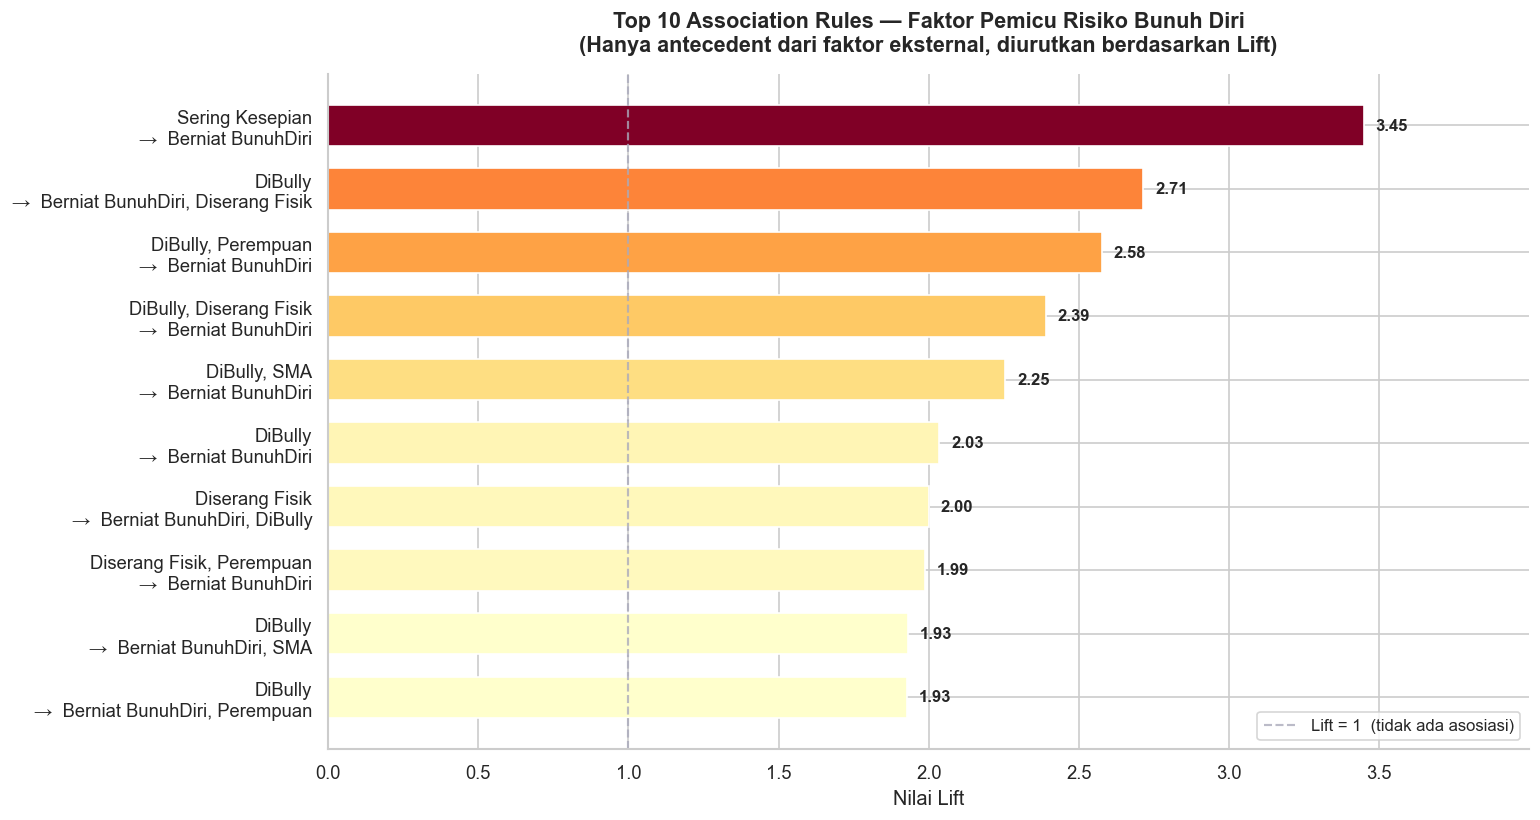

In [71]:
top10 = rules_external.head(10).copy()

top10['rule_label'] = (
    top10['antecedents_str'].str.replace('_', ' ')
    + '\n→  '
    + top10['consequents_str'].str.replace('_', ' ')
)
top10 = top10.sort_values('lift', ascending=True)

norm      = mcolors.Normalize(vmin=top10['lift'].min(), vmax=top10['lift'].max())
cmap_bar  = plt.colormaps['YlOrRd']
colors_b  = [cmap_bar(norm(v)) for v in top10['lift']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top10['rule_label'], top10['lift'],
               color=colors_b, edgecolor='white', height=0.65)

for bar, val in zip(bars, top10['lift']):
    ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=1, color='#aab', linestyle='--', linewidth=1.3,
           alpha=0.8, label='Lift = 1  (tidak ada asosiasi)')

ax.set_xlabel('Nilai Lift', fontsize=12)
ax.set_xlim(0, top10['lift'].max() + 0.55)
ax.set_title(
    'Top 10 Association Rules — Faktor Pemicu Risiko Bunuh Diri\n'
    '(Hanya antecedent dari faktor eksternal, diurutkan berdasarkan Lift)',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('arm_fig3_top_rules_lift.png', bbox_inches='tight')
plt.show()

### 12. Bubble Chart: Confidence vs Lift

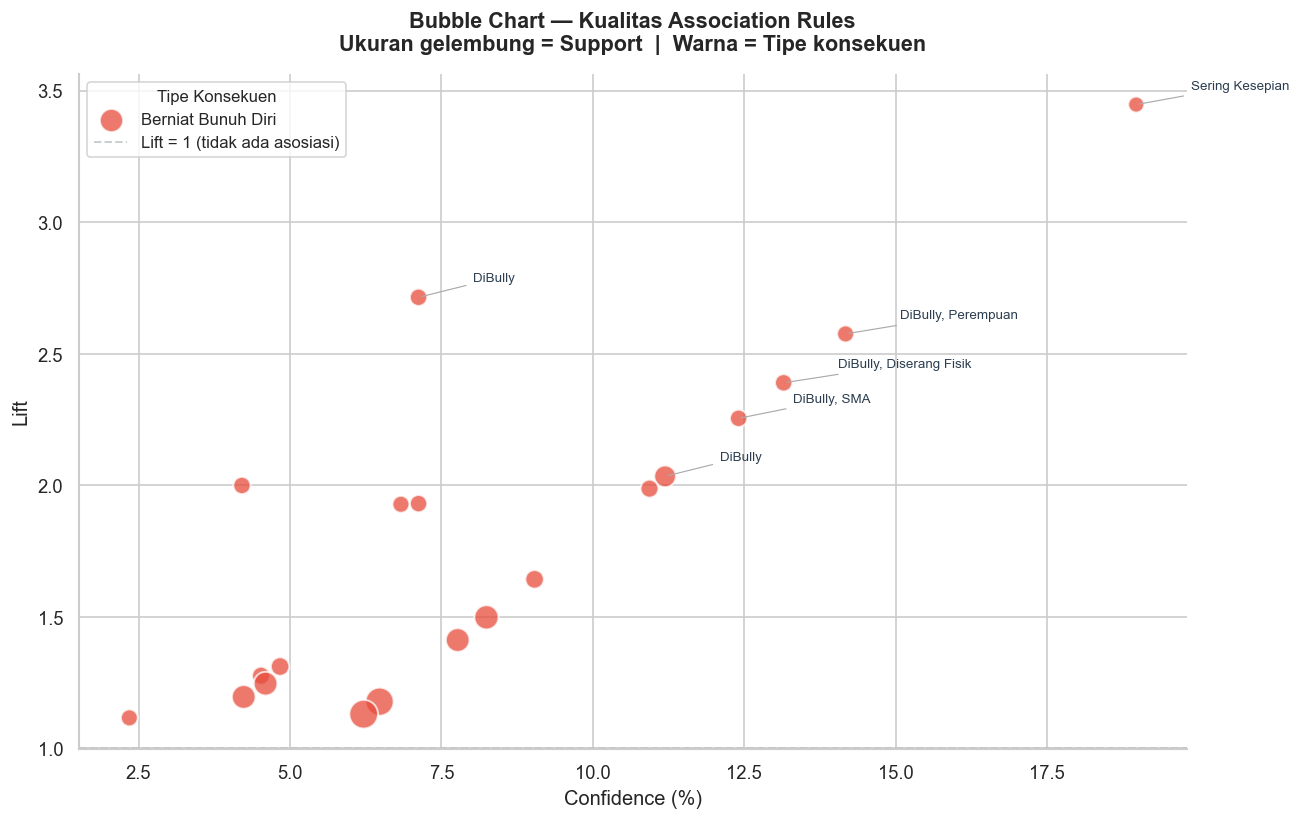

In [72]:
top20 = rules_external.head(20).copy()

# tipe konsekuen
def label_consequent(con_str):
    has_b = 'Berniat_BunuhDiri'     in con_str
    if has_b: return 'Berniat Bunuh Diri'
    return 'Lainnya'

top20['con_type'] = top20['consequents_str'].apply(label_consequent)

col_type = {
    'Berniat Bunuh Diri'  : '#e74c3c',

}

fig, ax = plt.subplots(figsize=(11, 7))

for ctype, grp in top20.groupby('con_type'):
    ax.scatter(
        grp['confidence'] * 100,
        grp['lift'],
        s=grp['support'] * 8000,
        alpha=0.75,
        color=col_type[ctype],
        edgecolors='white',
        linewidth=1.2,
        label=ctype,
        zorder=3,
    )

# 6 rules terpenting
for _, row in rules_external.head(6).iterrows():
    lbl = row['antecedents_str'].replace('_', ' ')
    ax.annotate(
        lbl,
        xy=(row['confidence'] * 100, row['lift']),
        xytext=(row['confidence'] * 100 + 0.9, row['lift'] + 0.06),
        fontsize=8,
        color='#2c3e50',
        arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.7),
    )

ax.axhline(y=1, color='#bdc3c7', linestyle='--', linewidth=1.2, alpha=0.8,
           label='Lift = 1 (tidak ada asosiasi)')

ax.set_xlabel('Confidence (%)', fontsize=12)
ax.set_ylabel('Lift', fontsize=12)
ax.set_title(
    'Bubble Chart — Kualitas Association Rules\n'
    'Ukuran gelembung = Support  |  Warna = Tipe konsekuen',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(title='Tipe Konsekuen', fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.savefig('arm_fig4_bubble.png', bbox_inches='tight')
plt.show()

### 13. Heatmap Confidence per Pasangan Rule

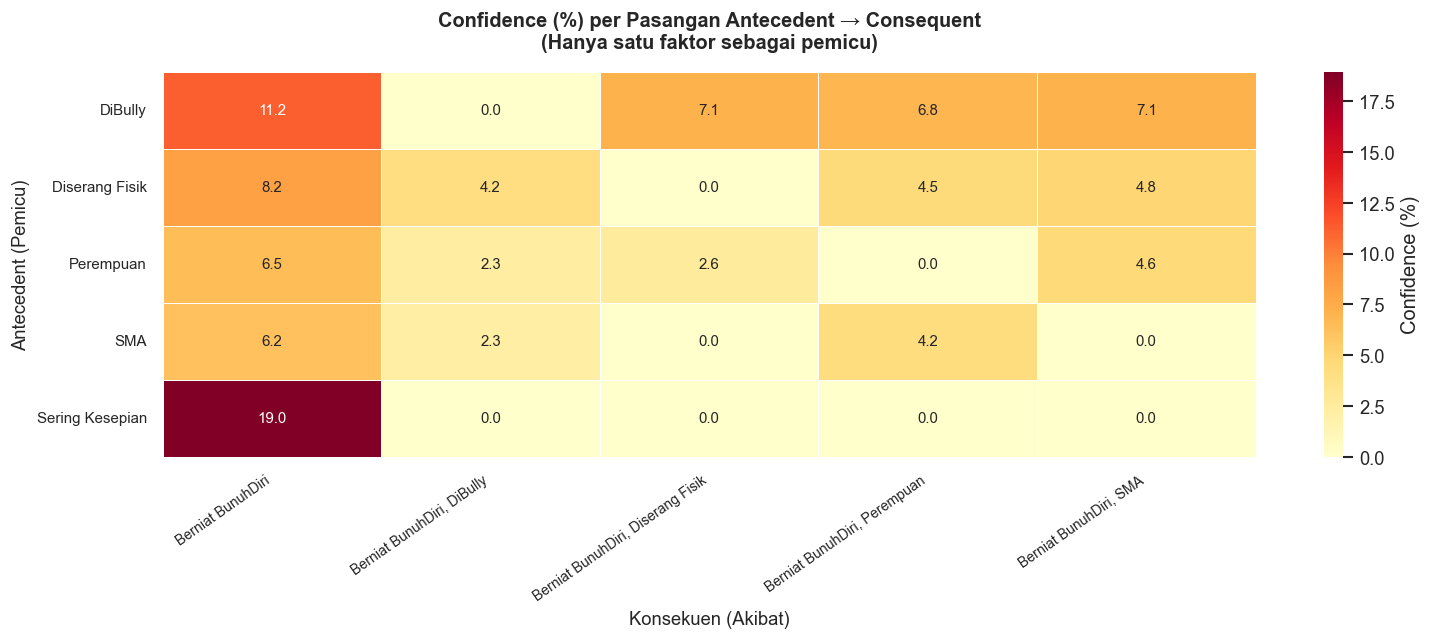

In [73]:
# Ambil rules dengan antecedent TUNGGAL
single_ext = rules_external[rules_external['antecedents'].apply(len) == 1].copy()
single_ext['ant'] = single_ext['antecedents_str'].str.replace('_', ' ')
single_ext['con'] = single_ext['consequents_str'].str.replace('_', ' ')

pivot = single_ext.pivot_table(
    index='ant', columns='con', values='confidence', aggfunc='max'
).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Confidence (%)'},
    annot_kws={'size': 9},
)
ax.set_title(
    'Confidence (%) per Pasangan Antecedent → Consequent\n'
    '(Hanya satu faktor sebagai pemicu)',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel('Konsekuen (Akibat)', fontsize=11)
ax.set_ylabel('Antecedent (Pemicu)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('arm_fig5_heatmap_conf.png', bbox_inches='tight')
plt.show()

### 14. Network Graph Hubungan Antar Faktor

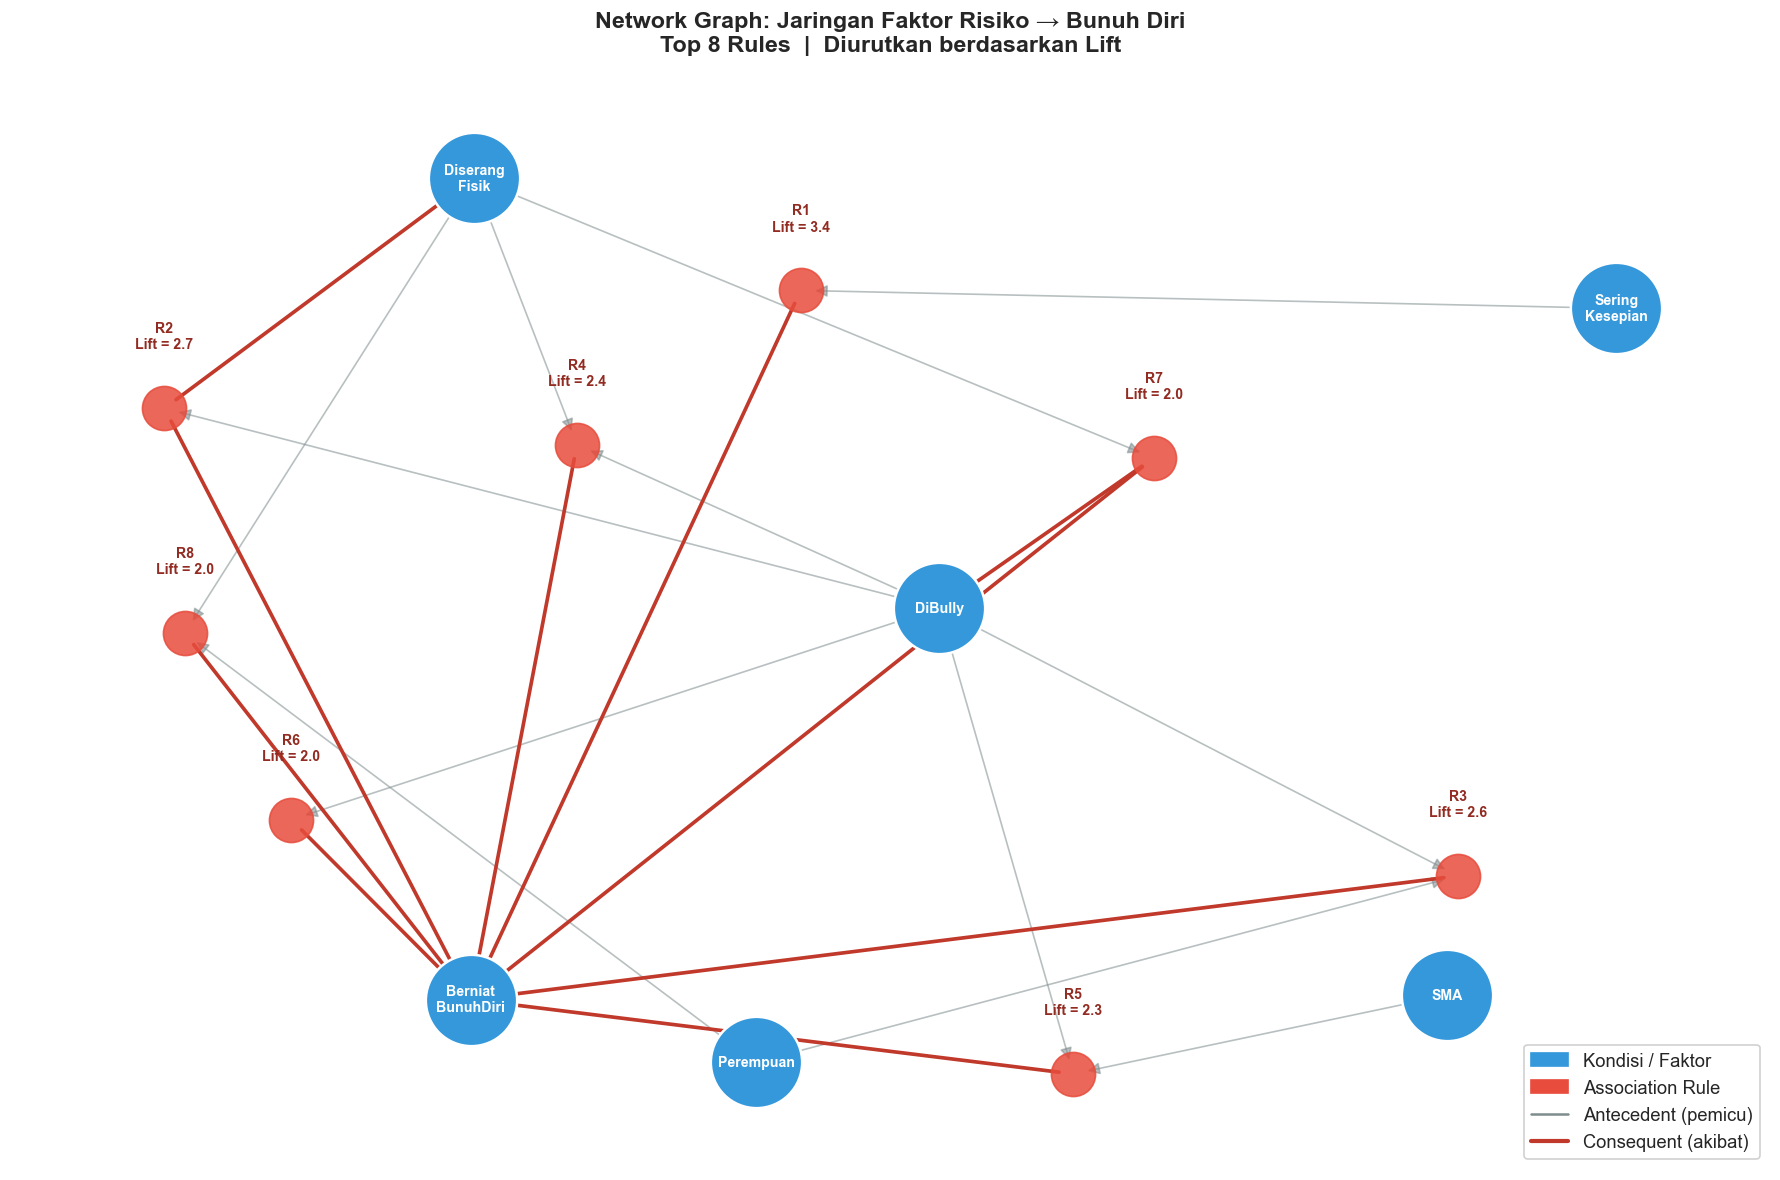

In [74]:
top_net = rules_external.sort_values('lift', ascending=False).head(8)

G = nx.DiGraph()
for idx, row in top_net.iterrows():
    rid = f"R{idx+1}"
    G.add_node(rid, node_type='rule', lift=row['lift'])
    for a in row['antecedents']:
        G.add_node(a, node_type='item')
        G.add_edge(a, rid, edge_type='antecedent')
    for c in row['consequents']:
        G.add_node(c, node_type='item')
        G.add_edge(rid, c, edge_type='consequent')

pos        = nx.spring_layout(G, k=2.8, iterations=120, seed=42)
item_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'item']
rule_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'rule']
ant_edges  = [(u,v) for u,v,d in G.edges(data=True) if d['edge_type'] == 'antecedent']
cons_edges = [(u,v) for u,v,d in G.edges(data=True) if d['edge_type'] == 'consequent']

fig, ax = plt.subplots(figsize=(15, 10))

nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_color='#3498db',
                       node_size=3000, edgecolors='white', linewidths=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, node_color='#e74c3c',
                       node_size=700, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=ant_edges,  edge_color='#7f8c8d',
                       arrows=True, arrowsize=15, alpha=0.55, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cons_edges, edge_color='#c0392b',
                       arrows=True, arrowsize=22, width=2.2, ax=ax)

item_labels = {n: n.replace('_', '\n') for n in item_nodes}
nx.draw_networkx_labels(G, pos, labels=item_labels,
                        font_size=8.5, font_weight='bold', font_color='white', ax=ax)

pos_up = {n: (x, y + 0.13) for n, (x, y) in pos.items()}
rule_labels = {n: f"{n}\nLift = {G.nodes[n]['lift']:.1f}" for n in rule_nodes}
nx.draw_networkx_labels(G, pos_up, labels=rule_labels,
                        font_size=8.5, font_color='#922b21', font_weight='bold', ax=ax)

legend_el = [
    mpatches.Patch(color='#3498db', label='Kondisi / Faktor'),
    mpatches.Patch(color='#e74c3c', label='Association Rule'),
    plt.Line2D([0],[0], color='#7f8c8d', lw=1.5, label='Antecedent (pemicu)'),
    plt.Line2D([0],[0], color='#c0392b', lw=2.5, label='Consequent (akibat)'),
]
ax.legend(handles=legend_el, loc='lower right', fontsize=11,
          frameon=True, facecolor='white', framealpha=0.9)

ax.set_title(
    'Network Graph: Jaringan Faktor Risiko → Bunuh Diri\n'
    'Top 8 Rules  |  Diurutkan berdasarkan Lift',
    fontsize=14, fontweight='bold', pad=20
)
ax.axis('off')
plt.tight_layout()
plt.savefig('arm_fig6_network.png', bbox_inches='tight')
plt.show()